# A/B тест: влияние email-рассылки на конверсию и ARPU

**Задача:** проверить, увеличивает ли промо-email конверсию в покупку и среднюю выручку на пользователя (ARPU) по сравнению с контрольной группой.

## Параметры теста

- `cr_control` — текущая конверсия (control)
- `cr_exp` — ожидаемая конверсия (experiment)
- `alpha` — уровень значимости (0.05)
- `power` — статистическая мощность (0.8)
- `n` — количество пользователей в каждой группе

In [2]:
import numpy as np
import pandas as pd
import math
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest
from IPython.display import display, Markdown


def calculate_sample_size(p1, p2, alpha=0.05, power=0.8):
    z_alpha = stats.norm.ppf(1 - alpha/2)
    z_beta = stats.norm.ppf(power)
    n = (z_alpha * math.sqrt(2 * ((p1+p2)/2) * (1 - (p1+p2)/2)) +
         z_beta * math.sqrt(p1*(1-p1) + p2*(1-p2))) ** 2 / ((p2 - p1) ** 2)
    return math.ceil(n)


cr_control = 0.10
cr_exp = 0.12
rev_control = 1200
rev_exp = 1350
alpha = 0.05
power = 0.8

n_required = calculate_sample_size(cr_control, cr_exp)
print(f'Для обнаружения роста конверсии с {cr_control:.0%} до {cr_exp:.0%}')
print(f'нужно по {n_required} пользователей в каждой группе (всего {n_required*2})')

Для обнаружения роста конверсии с 10% до 12%
нужно по 3841 пользователей в каждой группе (всего 7682)


## Почему размер выборки важен

При малой выборке (например, 550 человек) случайные колебания слишком велики и реальный эффект теряется на их фоне. При расчётном размере (3 850 человек) случайные колебания усредняются и настоящая разница между группами становится видимой.

In [3]:
n_control = 3850
n_exp = 3850
np.random.seed(42)

group = ['control']*n_control + ['experiment']*n_exp
converted_c = np.random.binomial(1, cr_control, n_control)
converted_exp = np.random.binomial(1, cr_exp, n_exp)
converted = np.concatenate([converted_c, converted_exp])

print('Первые 10 значений конверсии:', converted[:10])

Первые 10 значений конверсии: [0 1 0 0 0 0 0 0 0 0]


## Генерация выручки

Выручка моделируется через экспоненциальное распределение — соответствует реальной структуре e-commerce: большинство заказов небольшие, редкие — крупные. Выручка начисляется только конвертировавшимся пользователям.

In [4]:
revenue = np.zeros(n_control + n_exp)
revenue[:n_control][converted_c == 1] = np.random.exponential(
    rev_control, size=(converted_c == 1).sum())
revenue[n_control:][converted_exp == 1] = np.random.exponential(
    rev_exp, size=(converted_exp == 1).sum())

In [5]:
df = pd.DataFrame({
    'user_id': range(1, n_control + n_exp + 1),
    'group': group,
    'converted': converted,
    'revenue': revenue
})
print(df.head(13))

    user_id    group  converted      revenue
0         1  control          0     0.000000
1         2  control          1  6850.533976
2         3  control          0     0.000000
3         4  control          0     0.000000
4         5  control          0     0.000000
5         6  control          0     0.000000
6         7  control          0     0.000000
7         8  control          0     0.000000
8         9  control          0     0.000000
9        10  control          0     0.000000
10       11  control          0     0.000000
11       12  control          1  1667.352351
12       13  control          0     0.000000


## Базовые метрики по группам

In [6]:
print('Control:    пользователей =', df[df['group'] == 'control'].shape[0])
print('Control:    покупок =', df[(df['group'] == 'control') & (df['converted'] == 1)].shape[0])
print('Experiment: пользователей =', df[df['group'] == 'experiment'].shape[0])
print('Experiment: покупок =', df[(df['group'] == 'experiment') & (df['converted'] == 1)].shape[0])

Control:    пользователей = 3850
Control:    покупок = 371
Experiment: пользователей = 3850
Experiment: покупок = 452


In [7]:
control_avg_check = df[(df['group'] == 'control') & (df['converted'] == 1)]['revenue'].mean()
exp_avg_check = df[(df['group'] == 'experiment') & (df['converted'] == 1)]['revenue'].mean()
print('Control:    средний чек =', round(control_avg_check, 2))
print('Experiment: средний чек =', round(exp_avg_check, 2))

Control:    средний чек = 1094.88
Experiment: средний чек = 1295.24


## Z-тест для конверсии

In [8]:
z_result = proportions_ztest(
    count=[df[(df['group'] == 'control') & (df['converted'] == 1)].shape[0],
           df[(df['group'] == 'experiment') & (df['converted'] == 1)].shape[0]],
    nobs=[df[df['group'] == 'control'].shape[0],
          df[df['group'] == 'experiment'].shape[0]]
)

print('Z-тест для конверсии: z-статистика =', round(z_result[0], 4), 'p-value =', round(z_result[1], 6))

if z_result[1] < alpha:
    print('p-value < 0.05 => разница статистически значима')
else:
    print('p-value >= 0.05 => разница не значима')

Z-тест для конверсии: z-статистика = -2.9877 p-value = 0.002811
p-value < 0.05 => разница статистически значима


## T-тест для ARPU

In [9]:
t_stat, p_value_arpu = stats.ttest_ind(
    df[df['group'] == 'control']['revenue'],
    df[df['group'] == 'experiment']['revenue']
)
print('T-тест для ARPU: t-статистика =', round(t_stat, 4), 'p-value =', round(p_value_arpu, 6))

if p_value_arpu < alpha:
    print('p-value < 0.05 => разница статистически значима')
else:
    print('p-value >= 0.05 => разница не значима')

T-тест для ARPU: t-статистика = -3.7384 p-value = 0.000187
p-value < 0.05 => разница статистически значима


## Визуализация

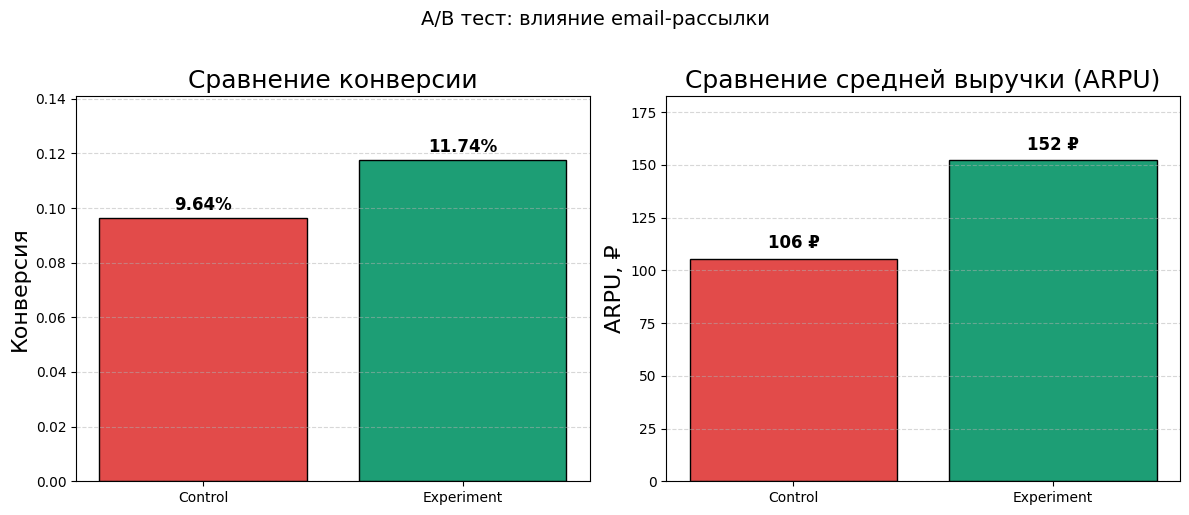

In [10]:
conv_control = df[df['group'] == 'control']['converted'].mean()
conv_exp = df[df['group'] == 'experiment']['converted'].mean()
revenue_control = df[df['group'] == 'control']['revenue'].mean()
revenue_exp = df[df['group'] == 'experiment']['revenue'].mean()
p_value_conv = z_result[1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

groups = ['Control', 'Experiment']
colors = ['#E24B4A', '#1D9E75']

bars = ax1.bar(groups, [conv_control, conv_exp], color=colors, edgecolor='black')
ax1.set_ylim(0, max(conv_control, conv_exp) * 1.2)
ax1.set_ylabel('Конверсия', fontsize=16)
ax1.set_title('Сравнение конверсии', fontsize=18)
ax1.grid(axis='y', linestyle='--', alpha=0.5)
for bar, val in zip(bars, [conv_control, conv_exp]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.2%}', ha='center', fontsize=12, fontweight='bold')

bars2 = ax2.bar(groups, [revenue_control, revenue_exp], color=colors, edgecolor='black')
ax2.set_ylim(0, max(revenue_control, revenue_exp) * 1.2)
ax2.set_ylabel('ARPU, ₽', fontsize=16)
ax2.set_title('Сравнение средней выручки (ARPU)', fontsize=18)
ax2.grid(axis='y', linestyle='--', alpha=0.5)
for bar, val in zip(bars2, [revenue_control, revenue_exp]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{val:.0f} ₽', ha='center', fontsize=12, fontweight='bold')

fig.suptitle('A/B тест: влияние email-рассылки', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('ab_test_results.png', dpi=150, bbox_inches='tight')
plt.show()

## Вывод

In [13]:
print('Вывод:')
print(f'Конверсия: control = {conv_control:.2%},  experiment = {conv_exp:.2%},  p-value = {p_value_conv:.6f}')
if p_value_conv < alpha:
    print('=> разница по конверсии значима')
else:
    print('=> разница по конверсии не значима')
print()
print(f'ARPU: control = {revenue_control:.0f} руб.,  experiment = {revenue_exp:.0f} руб.,  p-value = {p_value_arpu:.6f}')
if p_value_arpu < alpha:
    print('=> разница по ARPU значима')
else:
    print('=> разница по ARPU не значима')
print()
if p_value_conv < alpha and p_value_arpu < alpha:
    print('Рекомендация: внедрять email-рассылку')
else:
    print('Рекомендация: недостаточно данных для вывода')

Вывод:
Конверсия: control = 9.64%,  experiment = 11.74%,  p-value = 0.002811
=> разница по конверсии значима

ARPU: control = 106 руб.,  experiment = 152 руб.,  p-value = 0.000187
=> разница по ARPU значима

Рекомендация: внедрять email-рассылку
